<a href="https://colab.research.google.com/github/shriya-0802/OsteoArthritis/blob/main/Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
#  Ensemble of 4 CNN Models for Image Classification
#  Google Colab + Google Drive – <1 hour training, 90+% target
# ============================================================

# ------------------------------------
# 1. Mount Google Drive
# ------------------------------------
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ------------------------------------
# 2. Imports
# ------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input, Average
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Lambda



In [3]:
# ------------------------------------
# 3. Data paths (adjust if needed)
# ------------------------------------
train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
list_of_classes = ['Healthy','Moderate','Severe']


In [4]:
# 4. Load and preprocess dataframes with 5-class mapping then relabel to 3
def create_dataframe(directory):
    filepaths, labels = [], []
    classlist = sorted(os.listdir(directory))
    # Original 5 class names (in order of folder numbers 0..4)
    orig_classes = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
    for klass in classlist:
        try:
            idx = int(klass)
            label = orig_classes[idx]   # keep original 5-class label
        except:
            label = klass
        classpath = os.path.join(directory, klass)
        if not os.path.isdir(classpath):
            continue
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(label)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})

train_df = create_dataframe(train_path)
valid_df = create_dataframe(valid_path)
test_df = create_dataframe(test_path)

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")

# Relabel: map 5 classes to 3 final classes
def relabel_to_3(label):
    if label in ['Healthy', 'Doubtful', 'Minimal']:
        return 'Healthy'
    elif label == 'Moderate':
        return 'Moderate'
    elif label == 'Severe':
        return 'Severe'
    else:
        return label

for df in [train_df, test_df, valid_df]:
    df['labels'] = df['labels'].apply(relabel_to_3)

# Trim classes to 500 samples each (speeds up training)
def trim_classes(df, max_samples=500):
    df_trimmed = pd.DataFrame()
    for label in df['labels'].unique():
        group = df[df['labels'] == label]
        if len(group) > max_samples:
            group = group.sample(n=max_samples, random_state=42)
        df_trimmed = pd.concat([df_trimmed, group])
    return df_trimmed

train_df = trim_classes(train_df, max_samples=500)
print(f"After trimming: {len(train_df)}")



Train: 5790, Valid: 826, Test: 1656
After trimming: 1173


In [5]:
# 5. Data generators (all use 224x224)
batch_size = 20
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2]
)
test_valid_datagen = ImageDataGenerator()

# Note: now all generators use 3-class labels (because we relabeled)
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepaths', y_col='labels',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=True
)

valid_gen = test_valid_datagen.flow_from_dataframe(
    valid_df, x_col='filepaths', y_col='labels',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# Test generator (use same batch size logic as in your original code)
length = len(test_df)
test_batch_size = sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80], reverse=True)[0]
test_gen = test_valid_datagen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='labels',
    target_size=img_size, batch_size=test_batch_size,
    class_mode='categorical', shuffle=False
)

print(f"Test batch size: {test_batch_size}, test steps: {len(test_gen)}")



Found 1173 validated image filenames belonging to 3 classes.
Found 826 validated image filenames belonging to 3 classes.
Found 1656 validated image filenames belonging to 3 classes.
Test batch size: 72, test steps: 23


In [6]:
# 6. Load your saved models (5‑class outputs)
model_paths = [
    '/content/drive/MyDrive/Colab Notebooks/DenseNet121_3class_81.58%.keras',
    '/content/drive/MyDrive/Colab Notebooks/final_inceptionv3_model.keras',
    '/content/drive/MyDrive/Colab Notebooks/best_efficientnet.keras',
    '/content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras'
]

raw_models = []
for path in model_paths:
    try:
        model = load_model(path)
        raw_models.append(model)
        print(f"Loaded {os.path.basename(path)}")
    except Exception as e:
        print(f"Could not load {os.path.basename(path)}: {e}")

if len(raw_models) == 0:
    raise RuntimeError("No models loaded. Please check paths.")


Loaded DenseNet121_3class_81.58%.keras
Loaded final_inceptionv3_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded best_efficientnet.keras
Loaded best_mobilenet.keras


In [7]:
from tensorflow.keras.layers import Lambda

In [8]:
def make_3class_model(model_5c):
    input_tensor = Input(shape=(224,224,3))
    x = model_5c(input_tensor)
    # Define a lambda to map 5 outputs to 3
    def map_output(y):
        healthy = y[:,0] + y[:,1] + y[:,2]
        moderate = y[:,3]
        severe = y[:,4]
        return tf.stack([healthy, moderate, severe], axis=1)
    out = Lambda(map_output, output_shape=(3,))(x)
    return Model(inputs=input_tensor, outputs=out)
# Wrap each model
adapted_models = [make_3class_model(m) for m in raw_models]



In [9]:
# 6. Load your saved models (check output shape)
model_paths = [
    '/content/drive/MyDrive/Colab Notebooks/DenseNet121_3class_81.58%.keras',
    '/content/drive/MyDrive/Colab Notebooks/final_inceptionv3_model.keras',
    '/content/drive/MyDrive/Colab Notebooks/best_efficientnet.keras',
    '/content/drive/MyDrive/Colab Notebooks/best_mobilenet.keras'
]

raw_models = []
for path in model_paths:
    try:
        model = load_model(path)
        num_classes = model.output_shape[-1]
        print(f"Loaded {os.path.basename(path)} with {num_classes} output classes")
        raw_models.append((model, num_classes))
    except Exception as e:
        print(f"Could not load {os.path.basename(path)}: {e}")

# 7. Function to wrap a 5‑class model into a 3‑class model
def make_3class_model(model_5c):
    input_tensor = Input(shape=(224,224,3))
    x = model_5c(input_tensor)
    def map_5_to_3(y):
        healthy = y[:,0] + y[:,1] + y[:,2]
        moderate = y[:,3]
        severe = y[:,4]
        return tf.stack([healthy, moderate, severe], axis=1)
    out = Lambda(map_5_to_3, output_shape=(3,))(x)
    return Model(inputs=input_tensor, outputs=out)

# Create a list of final models (all output 3 classes)
final_models = []
for model, num_classes in raw_models:
    if num_classes == 3:
        final_models.append(model)
        print(f"Using {model.name} directly (3‑class)")
    elif num_classes == 5:
        adapted = make_3class_model(model)
        final_models.append(adapted)
        print(f"Adapted {model.name} to 3‑class")
    else:
        print(f"Model has {num_classes} classes – skipping")

if len(final_models) == 0:
    raise RuntimeError("No compatible models found.")

print(f"Using {len(final_models)} models for ensemble.")

Loaded DenseNet121_3class_81.58%.keras with 3 output classes
Loaded final_inceptionv3_model.keras with 5 output classes
Loaded best_efficientnet.keras with 5 output classes
Loaded best_mobilenet.keras with 5 output classes
Using functional directly (3‑class)
Adapted functional to 3‑class
Adapted functional to 3‑class
Adapted functional to 3‑class
Using 4 models for ensemble.


In [10]:
# 8. Build ensemble (average of all final models)
input_tensor = Input(shape=(224,224,3))
outputs = [m(input_tensor) for m in final_models]
output_tensor = Average()(outputs)

ensemble_model = Model(inputs=input_tensor, outputs=output_tensor)
ensemble_model.compile(Adamax(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [11]:
# 9. Evaluate before fine‑tuning
def evaluate_model(model, test_gen):
    preds = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.labels
    acc = np.mean(y_pred == y_true)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))
    return acc

print("\n=== Ensemble accuracy before fine‑tuning ===")
initial_acc = evaluate_model(ensemble_model, test_gen)




=== Ensemble accuracy before fine‑tuning ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 1662s 71s/step
Accuracy: 0.7754
              precision    recall  f1-score   support

     Healthy       0.85      0.91      0.88      1382
    Moderate       0.19      0.10      0.13       223
      Severe       0.07      0.06      0.06        51

    accuracy                           0.78      1656
   macro avg       0.37      0.36      0.36      1656
weighted avg       0.73      0.78      0.75      1656



In [12]:
# 10. Fine‑tune the ensemble (fast)
epochs = 10   # <1 hour on T4 GPU
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=2, min_lr=1e-6)
]

print("\n=== Fine‑tuning ensemble ===")
history = ensemble_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)



=== Fine‑tuning ensemble ===
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1981s 32s/step - accuracy: 0.5311 - loss: 0.9222 - val_accuracy: 0.6792 - val_loss: 0.7857 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1862s 31s/step - accuracy: 0.5720 - loss: 0.8674 - val_accuracy: 0.7809 - val_loss: 0.7229 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1819s 31s/step - accuracy: 0.6223 - loss: 0.8160 - val_accuracy: 0.6998 - val_loss: 0.7568 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1847s 32s/step - accuracy: 0.6240 - loss: 0.8129 - val_accuracy: 0.8136 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1812s 31s/step - accuracy: 0.6164 - loss: 0.7934 - val_accuracy: 0.8172 - val_loss: 0.6062 - learning_rate: 0.0010
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1853s 32s/step - accuracy: 0.6445 - loss: 0.7814 - val_accuracy: 0.8559 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1860s 32s/step


=== Ensemble accuracy after fine‑tuning ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 1597s 69s/step
Accuracy: 0.8466
              precision    recall  f1-score   support

     Healthy       0.89      0.96      0.92      1382
    Moderate       0.44      0.28      0.34       223
      Severe       0.79      0.29      0.43        51

    accuracy                           0.85      1656
   macro avg       0.70      0.51      0.56      1656
weighted avg       0.82      0.85      0.83      1656


🎯 Accuracy improvement: 0.0713
✅ Final test accuracy: 0.8466


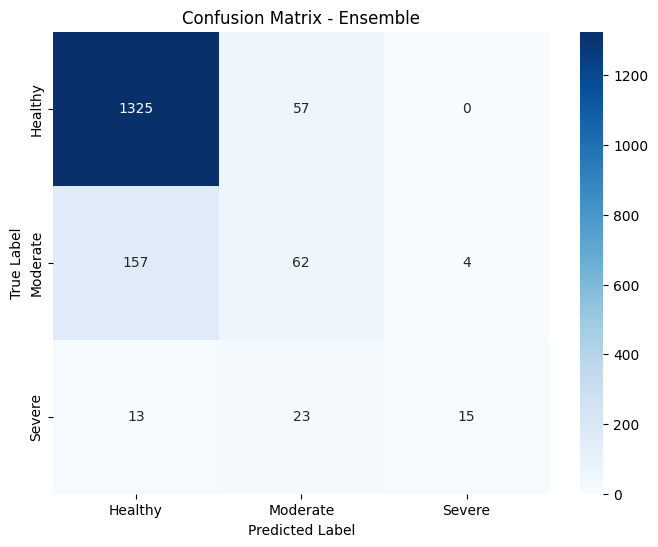

In [13]:
# 11. Final evaluation
print("\n=== Ensemble accuracy after fine‑tuning ===")
final_acc = evaluate_model(ensemble_model, test_gen)

print(f"\n🎯 Accuracy improvement: {final_acc - initial_acc:.4f}")
print(f"✅ Final test accuracy: {final_acc:.4f}")

# 12. Confusion matrix
preds = ensemble_model.predict(test_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title('Confusion Matrix - Ensemble')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [16]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array



=== Testing on a random image from test set ===


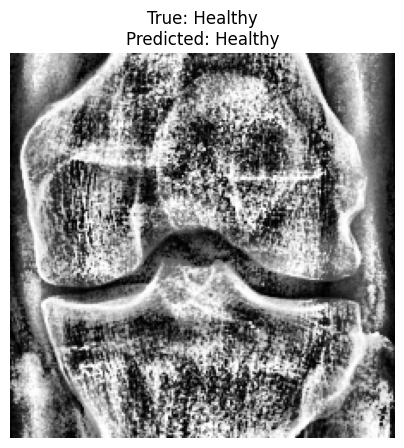

Image path: /content/drive/MyDrive/Kaggle_Dataset/archive (3)/test/0/9854566L.png
True label: Healthy
Predicted label: Healthy


In [17]:
# ============================================================
# 13. Test on a single image (random from test set)
# ============================================================
print("\n=== Testing on a random image from test set ===")

# Get a random image path from the test dataframe
random_index = random.randint(0, len(test_df)-1)
test_image_path = test_df.iloc[random_index]['filepaths']
true_label = test_df.iloc[random_index]['labels']

# Load and preprocess the image
img = load_img(test_image_path, target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict using the ensemble
preds = ensemble_model.predict(img_array, verbose=0)
pred_class_idx = np.argmax(preds)
pred_class = list(test_gen.class_indices.keys())[pred_class_idx]

# Display the image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"True: {true_label}\nPredicted: {pred_class}")
plt.axis('off')
plt.show()

print(f"Image path: {test_image_path}")
print(f"True label: {true_label}")
print(f"Predicted label: {pred_class}")